In [ ]:
# Load the data file - and perform EDA to understand the data, in preparation for building an ML model to predict whether someone will repay or default
# a loan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.pandas.set_option("display.max_columns", None)

In [2]:
# Set style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [6]:
ml_data_file = "../data/processed/ml_training_data.csv"

In [4]:
def load_data(filepath):
    try:
        df = pd.read_csv(filepath)
        print(f"Loaded {len(df)} applicants' data with {df.shape[1]} features.")
        return df
    except FileNotFoundError:
        print(f"Error, {filepath} not found.")
        return None

In [7]:
df = load_data(ml_data_file)

Loaded 1000 applicants' data with 34 features.


In [8]:
df.head()

,monthly_avg_income,income_volatility_cv,income_trend_6months,num_income_sources,monthly_net_cashflow,months_negative_cashflow,balance_min,months_balance_below_500,fuliza_frequency,fuliza_repayment_rate,debt_to_income_ratio,avg_fuliza_amount,transaction_frequency,savings_rate,expense_consistency_cv,applicant_id,age,years_employed,max_years_possible,account_age_months,past_loans_count,past_defaults_count,past_repaid_loans,current_debts_count,credit_score,previous_max_balance,overdraft_history,days_account_active,employment_Salaried,employment_Self-employed,employment_Student/Other,education_level_encoded,loan_status,creditworthiness_score
0,74245.71,0.1315,10.34,3,18845.22,0,-33545.97,3,0.08,1.0000,0.0014,1266.12,60.75,0.0167,0.1065,1,44,2.8,26,69,2,0,2,0,736.0,186329,0,1.00,True,False,False,2,1,84.23
1,22165.92,0.2428,33.43,5,-6491.92,11,-73563.35,12,1.08,0.0000,0.0952,1947.99,76.58,0.0023,0.1049,2,38,1.5,20,47,1,0,1,0,678.0,32481,2,0.65,False,False,True,1,0,46.83
2,112492.88,0.1652,15.68,5,85153.46,0,15639.81,0,2.25,0.9448,0.0473,2362.91,118.58,0.0105,0.1216,3,42,5.1,24,79,2,0,2,1,701.0,58992,5,0.88,False,True,False,1,1,90.64
3,120165.12,0.1760,13.44,5,89149.91,0,9467.30,0,1.83,0.8979,0.0435,2851.47,119.25,0.0124,0.0909,4,25,0.8,7,34,2,2,0,0,505.0,57377,5,0.88,False,True,False,1,1,85.43
4,68475.47,0.1315,10.34,3,20103.24,0,-25102.72,2,0.00,1.0000,0.0000,0.00,62.67,0.0135,0.0981,5,33,2.4,15,52,3,0,3,1,704.0,58585,1,0.89,True,False,False,2,1,79.12


In [9]:
df[df["applicant_id"] == 432]

,monthly_avg_income,income_volatility_cv,income_trend_6months,num_income_sources,monthly_net_cashflow,months_negative_cashflow,balance_min,months_balance_below_500,fuliza_frequency,fuliza_repayment_rate,debt_to_income_ratio,avg_fuliza_amount,transaction_frequency,savings_rate,expense_consistency_cv,applicant_id,age,years_employed,max_years_possible,account_age_months,past_loans_count,past_defaults_count,past_repaid_loans,current_debts_count,credit_score,previous_max_balance,overdraft_history,days_account_active,employment_Salaried,employment_Self-employed,employment_Student/Other,education_level_encoded,loan_status,creditworthiness_score
431,120681.55,0.269,5.44,5,91923.13,0,8075.0,0,2.08,0.8465,0.0409,2369.38,119.58,0.0152,0.0849,432,29,1.7,11,40,1,1,0,0,678.0,43582,2,0.7,False,True,False,0,0,52.25


In [14]:
def dataset_overview(df):
    """Provide high-level overview of the dataset"""
    print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    
    # Target variable distribution
    print(f"\nTarget Variable Distribution (loan_status):")
    target_counts = df["loan_status"].value_counts()
    target_pct = df['loan_status'].value_counts(normalize=True)
    print(target_pct)
    
    # Missing values
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print(f"\n Missing Values: None")
    else:
        print(f"\n Missing Values:")
        missing_cols = missing[missing > 0]
        for col, count in missing_cols.items():
            print(f"   - {col}: {count} ({count/len(df)*100:.1f}%)")
    
    # Data types
    print(f"\n Data Types:")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"   - {dtype}: {count} columns")
    
    # Numeric features summary
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print(f"\n Numeric Features: {len(numeric_cols)}")
    
    return numeric_cols

In [15]:
dataset_overview(df)

Dataset Shape: 1000 rows × 40 columns

Target Variable Distribution (loan_status):
loan_status
1    0.75
0    0.25
Name: proportion, dtype: float64

 Missing Values:
   - credit_score: 642 (64.2%)

 Data Types:
   - float64: 16 columns
   - int64: 15 columns
   - object: 6 columns
   - bool: 3 columns

 Numeric Features: 31


Index(['applicant_id', 'monthly_avg_income', 'income_volatility_cv',
       'income_trend_6months', 'num_income_sources', 'monthly_net_cashflow',
       'months_negative_cashflow', 'balance_min', 'months_balance_below_500',
       'fuliza_frequency', 'fuliza_repayment_rate', 'debt_to_income_ratio',
       'avg_fuliza_amount', 'transaction_frequency', 'savings_rate',
       'expense_consistency_cv', 'age', 'years_employed', 'max_years_possible',
       'account_age_months', 'past_loans_count', 'past_defaults_count',
       'past_repaid_loans', 'current_debts_count', 'credit_score',
       'previous_max_balance', 'overdraft_history', 'days_account_active',
       'education_level_encoded', 'loan_status', 'creditworthiness_score'],
      dtype='object')

In [39]:
def target_analysis(df):
    """Analyze target variable distribution"""
    # Create labels for better visualization
    df_plot = df.copy()
    df_plot['loan_status_label'] = df_plot['loan_status'].map({0: 'Default', 1: 'Repaid'})
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot using seaborn
    sns.countplot(data=df_plot, x='loan_status_label', palette=['#e74c3c', '#2ecc71'], 
                  ax=axes[0], order=['Default', 'Repaid'])
    axes[0].set_title('Loan Status Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Loan Status', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    
    # Add count labels on bars
    for container in axes[0].containers:
        axes[0].bar_label(container, fontweight='bold')
    
    # Pie chart
    target_counts = df['loan_status'].value_counts()
    colors = ['#e74c3c', '#2ecc71']
    axes[1].pie(target_counts.values, labels=['Default (0)', 'Repaid (1)'], 
                autopct='%1.1f%%', colors=colors, startangle=90,
                textprops={'fontsize': 12, 'fontweight': 'bold'})
    axes[1].set_title('Loan Status Proportion', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


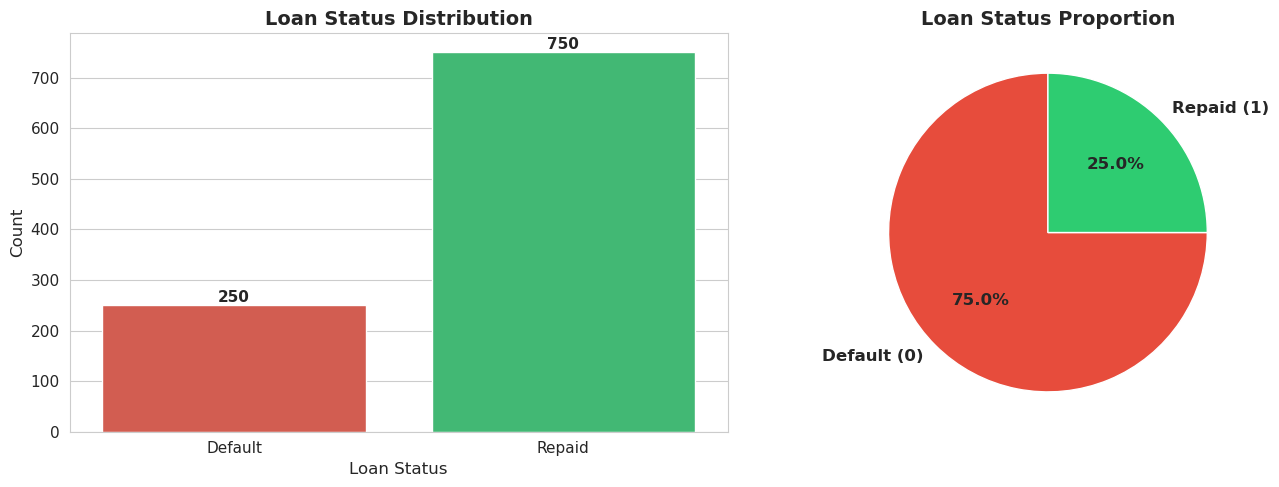

In [40]:
target_analysis(df)

In [22]:
def demographics_analysis(df):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Age distribution
    sns.histplot(data=df, x='age', bins=30, kde=True, color='skyblue', ax=axes[0, 0])
    axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {df["age"].mean():.1f}')
    axes[0, 0].set_title('Age Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    
    # Employment type
    if 'employment_type' in df.columns:
        emp_data = df['employment_type'].value_counts().reset_index()
        emp_data.columns = ['employment_type', 'count']
        sns.barplot(data=emp_data, y='employment_type', x='count', palette='Set2', ax=axes[0, 1])
        axes[0, 1].set_title('Employment Type Distribution', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Count')
        axes[0, 1].set_ylabel('Employment Type')
    
    # Education level
    if 'education_level' in df.columns:
        sns.countplot(data=df, x='education_level', palette='Set3', ax=axes[0, 2],
                     order=['Primary', 'Secondary', 'Tertiary'])
        axes[0, 2].set_title('Education Level Distribution', fontsize=12, fontweight='bold')
        axes[0, 2].set_ylabel('Count')
        axes[0, 2].tick_params(axis='x', rotation=45)
        for container in axes[0, 2].containers:
            axes[0, 2].bar_label(container)
    
    # Years employed
    sns.histplot(data=df, x='years_employed', bins=30, kde=True, color='plum', ax=axes[1, 0])
    axes[1, 0].axvline(df['years_employed'].mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {df["years_employed"].mean():.1f}')
    axes[1, 0].set_title('Years Employed Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    
    # Gender
    if 'gender' in df.columns:
        gender_counts = df['gender'].value_counts()
        axes[1, 1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
                       colors=sns.color_palette('pastel'), startangle=90)
        axes[1, 1].set_title('Gender Distribution', fontsize=12, fontweight='bold')
    else:
        axes[1, 1].axis('off')
    
    # Location
    if 'location' in df.columns:
        loc_data = df['location'].value_counts().head(10).reset_index()
        loc_data.columns = ['location', 'count']
        sns.barplot(data=loc_data, y='location', x='count', palette='viridis', ax=axes[1, 2])
        axes[1, 2].set_title('Top 10 Locations', fontsize=12, fontweight='bold')
        axes[1, 2].set_xlabel('Count')
        axes[1, 2].set_ylabel('Location')
    else:
        axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

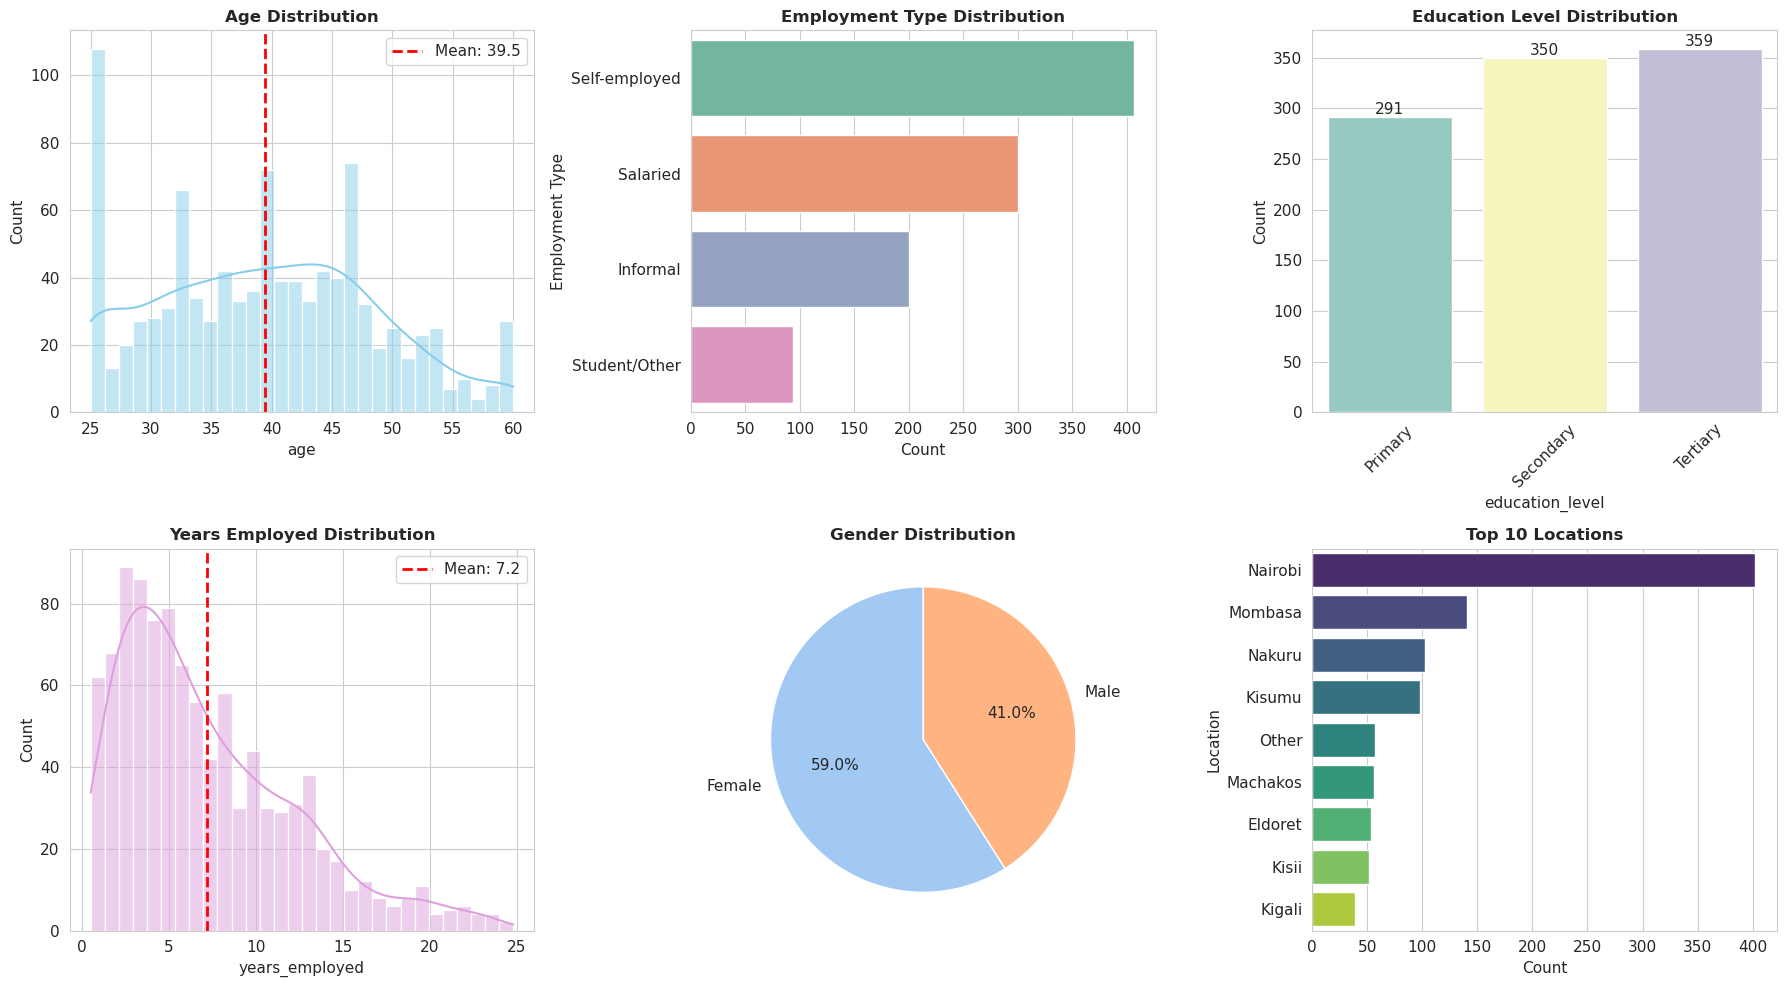

In [41]:
demographics_analysis(df)

In [24]:
def income_analysis(df):
    """Analyze income-related features"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Monthly average income
    sns.histplot(data=df, x='monthly_avg_income', bins=50, kde=True, color='green', ax=axes[0, 0])
    axes[0, 0].axvline(df['monthly_avg_income'].median(), color='red', linestyle='--', linewidth=2,
                       label=f'Median: KES {df["monthly_avg_income"].median():.0f}')
    axes[0, 0].set_title('Monthly Average Income Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Income (KES)')
    axes[0, 0].legend()
    
    # Income volatility
    sns.histplot(data=df, x='income_volatility_cv', bins=50, kde=True, color='orange', ax=axes[0, 1])
    axes[0, 1].axvline(df['income_volatility_cv'].mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {df["income_volatility_cv"].mean():.3f}')
    axes[0, 1].set_title('Income Volatility (CV)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Coefficient of Variation')
    axes[0, 1].legend()
    
    # Income trend
    sns.histplot(data=df, x='income_trend_6months', bins=50, kde=True, color='blue', ax=axes[1, 0])
    axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
    axes[1, 0].set_title('Income Trend (6 months)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('% Change')
    axes[1, 0].legend()
    
    # Number of income sources
    sns.countplot(data=df, x='num_income_sources', palette='viridis', ax=axes[1, 1])
    axes[1, 1].set_title('Number of Income Sources', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Number of Sources')
    axes[1, 1].set_ylabel('Count')
    for container in axes[1, 1].containers:
        axes[1, 1].bar_label(container)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n Income Statistics:")
    print(f"   - Avg Monthly Income: KES {df['monthly_avg_income'].mean():.2f} (±{df['monthly_avg_income'].std():.2f})")
    print(f"   - Min Income: KES {df['monthly_avg_income'].min():.2f}")
    print(f"   - Max Income: KES {df['monthly_avg_income'].max():.2f}")
    print(f"   - Median Income: KES {df['monthly_avg_income'].median():.2f}")
    print(f"   - Income Volatility: {df['income_volatility_cv'].mean():.3f} (±{df['income_volatility_cv'].std():.3f})")

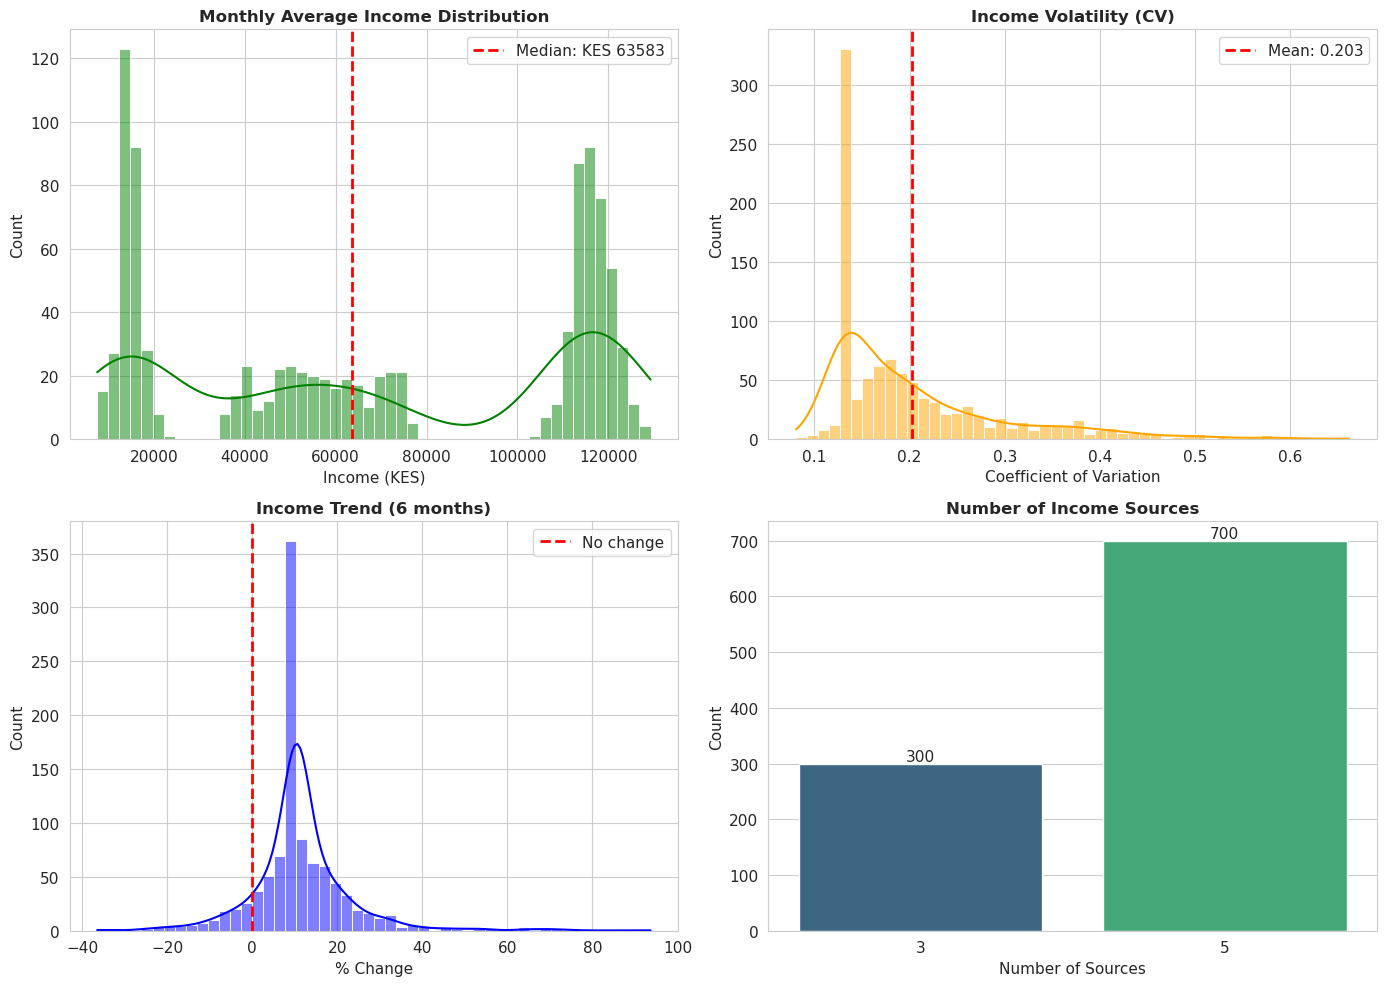


 Income Statistics:
   - Avg Monthly Income: KES 68573.45 (±43471.67)
   - Min Income: KES 7540.19
   - Max Income: KES 129286.89
   - Median Income: KES 63582.60
   - Income Volatility: 0.203 (±0.092)


In [42]:
income_analysis(df)

In [26]:
def debt_analysis(df):
    """Analyze debt-related features"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Fuliza frequency
    sns.histplot(data=df, x='fuliza_frequency', bins=50, kde=True, color='red', ax=axes[0, 0])
    axes[0, 0].axvline(df['fuliza_frequency'].mean(), color='darkred', linestyle='--', linewidth=2,
                       label=f'Mean: {df["fuliza_frequency"].mean():.2f}')
    axes[0, 0].set_title('Fuliza Frequency (per month)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Frequency')
    axes[0, 0].legend()
    
    # Fuliza repayment rate
    sns.histplot(data=df, x='fuliza_repayment_rate', bins=50, kde=True, color='teal', ax=axes[0, 1])
    axes[0, 1].axvline(df['fuliza_repayment_rate'].mean(), color='darkcyan', linestyle='--', linewidth=2,
                       label=f'Mean: {df["fuliza_repayment_rate"].mean():.3f}')
    axes[0, 1].set_title('Fuliza Repayment Rate', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Repayment Rate')
    axes[0, 1].legend()
    
    # Debt to income ratio
    sns.histplot(data=df, x='debt_to_income_ratio', bins=50, kde=True, color='purple', ax=axes[1, 0])
    axes[1, 0].axvline(df['debt_to_income_ratio'].mean(), color='darkviolet', linestyle='--', linewidth=2,
                       label=f'Mean: {df["debt_to_income_ratio"].mean():.3f}')
    axes[1, 0].set_title('Debt to Income Ratio', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Ratio')
    axes[1, 0].legend()
    
    # Average Fuliza amount
    sns.histplot(data=df, x='avg_fuliza_amount', bins=50, kde=True, color='coral', ax=axes[1, 1])
    axes[1, 1].axvline(df['avg_fuliza_amount'].mean(), color='darkred', linestyle='--', linewidth=2,
                       label=f'Mean: KES {df["avg_fuliza_amount"].mean():.0f}')
    axes[1, 1].set_title('Average Fuliza Amount', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Amount (KES)')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n Debt Statistics:")
    print(f"   - Avg Fuliza Frequency: {df['fuliza_frequency'].mean():.2f}/month (±{df['fuliza_frequency'].std():.2f})")
    print(f"   - Avg Fuliza Repayment Rate: {df['fuliza_repayment_rate'].mean():.3f} (±{df['fuliza_repayment_rate'].std():.3f})")
    print(f"   - Avg Debt to Income: {df['debt_to_income_ratio'].mean():.3f} (±{df['debt_to_income_ratio'].std():.3f})")
    print(f"   - Avg Fuliza Amount: KES {df['avg_fuliza_amount'].mean():.2f} (±{df['avg_fuliza_amount'].std():.2f})")

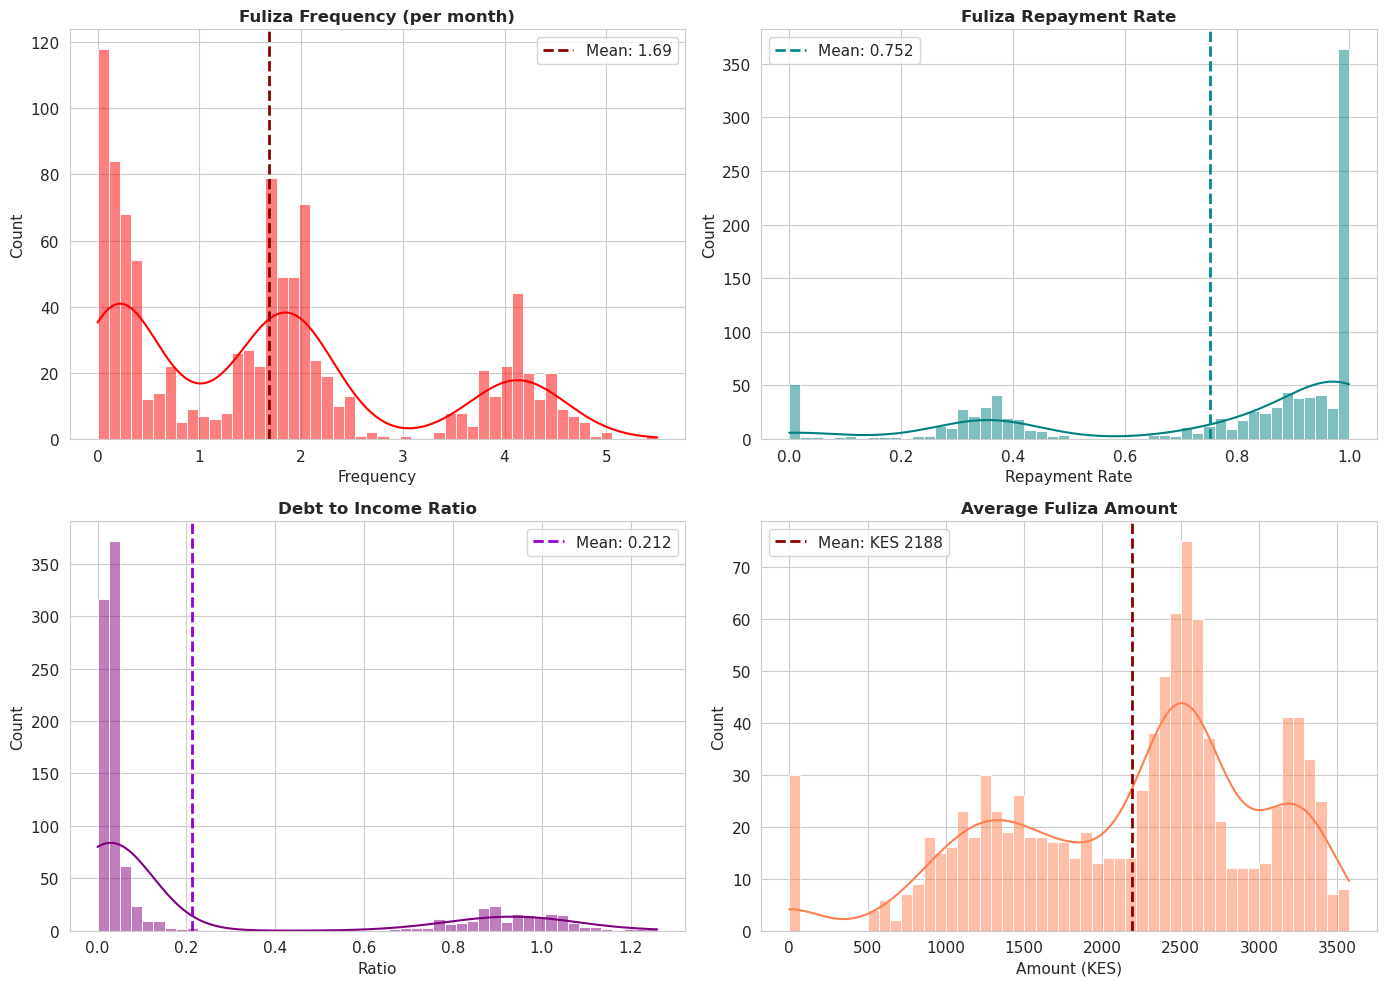


 Debt Statistics:
   - Avg Fuliza Frequency: 1.69/month (±1.44)
   - Avg Fuliza Repayment Rate: 0.752 (±0.313)
   - Avg Debt to Income: 0.212 (±0.365)
   - Avg Fuliza Amount: KES 2188.18 (±838.58)


In [43]:
debt_analysis(df)

In [28]:
def cashflow_analysis(df):
    """Analyze cash flow features"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Monthly net cashflow
    sns.histplot(data=df, x='monthly_net_cashflow', bins=50, kde=True, color='green', ax=axes[0, 0])
    axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Break-even')
    axes[0, 0].axvline(df['monthly_net_cashflow'].mean(), color='blue', linestyle='--', linewidth=2,
                       label=f'Mean: KES {df["monthly_net_cashflow"].mean():.0f}')
    axes[0, 0].set_title('Monthly Net Cashflow', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Cashflow (KES)')
    axes[0, 0].legend()
    
    # Months with negative cashflow
    sns.countplot(data=df, x='months_negative_cashflow', palette='Reds', ax=axes[0, 1])
    axes[0, 1].set_title('Months with Negative Cashflow', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Number of Months')
    axes[0, 1].set_ylabel('Count')
    
    # Minimum balance
    sns.histplot(data=df, x='balance_min', bins=50, kde=True, color='orange', ax=axes[1, 0])
    axes[1, 0].axvline(500, color='red', linestyle='--', linewidth=2, label='KES 500 threshold')
    axes[1, 0].set_title('Minimum Balance', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Balance (KES)')
    axes[1, 0].legend()
    
    # Months with balance below 500
    sns.countplot(data=df, x='months_balance_below_500', palette='YlOrRd', ax=axes[1, 1])
    axes[1, 1].set_title('Months with Balance < KES 500', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Number of Months')
    axes[1, 1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()

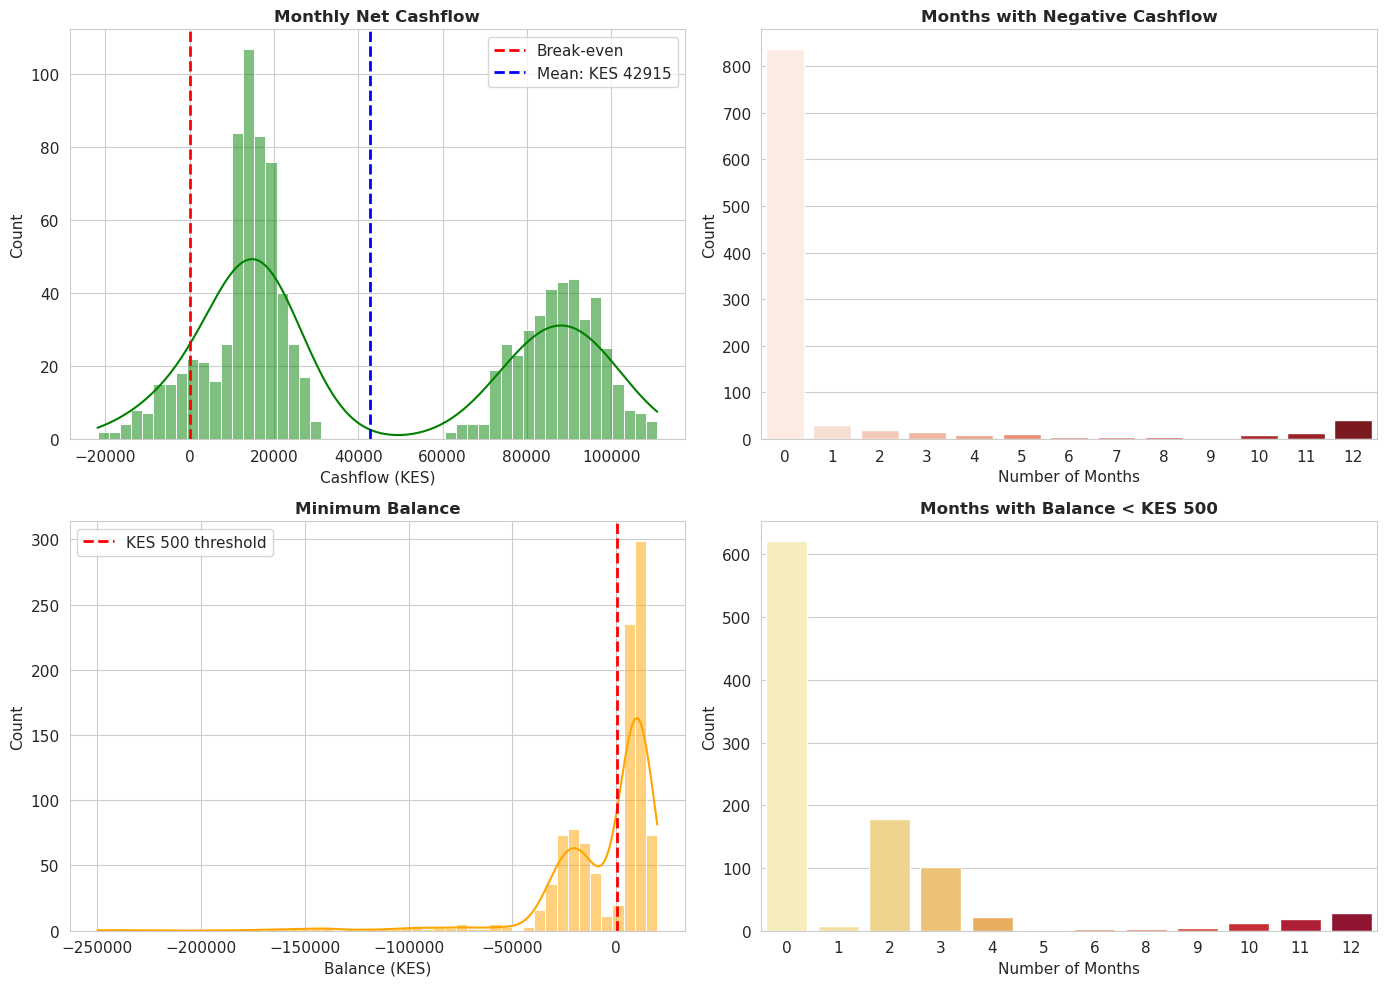

In [44]:
cashflow_analysis(df)

In [30]:
def features_by_target(df):
    """Compare key features between Repaid vs Default"""
    
    # Create labels
    df_plot = df.copy()
    df_plot['loan_status_label'] = df_plot['loan_status'].map({0: 'Default', 1: 'Repaid'})
    
    key_features = [
        'monthly_avg_income',
        'income_volatility_cv',
        'fuliza_frequency',
        'debt_to_income_ratio',
        'monthly_net_cashflow',
        'savings_rate'
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, feature in enumerate(key_features):
        sns.boxplot(data=df_plot, x='loan_status_label', y=feature, 
                   palette=['#e74c3c', '#2ecc71'], ax=axes[idx])
        axes[idx].set_title(f'{feature} by Loan Status', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Loan Status')
        axes[idx].set_ylabel(feature)
    
    plt.tight_layout()
    plt.show()
    
    # Print mean comparison
    print("\n Mean Comparison (Repaid vs Default):")
    for feature in key_features:
        repaid_mean = df[df['loan_status']==1][feature].mean()
        default_mean = df[df['loan_status']==0][feature].mean()
        print(f"   {feature}:")
        print(f"      - Repaid: {repaid_mean:.3f}")
        print(f"      - Default: {default_mean:.3f}")
        print(f"      - Difference: {repaid_mean - default_mean:.3f}")

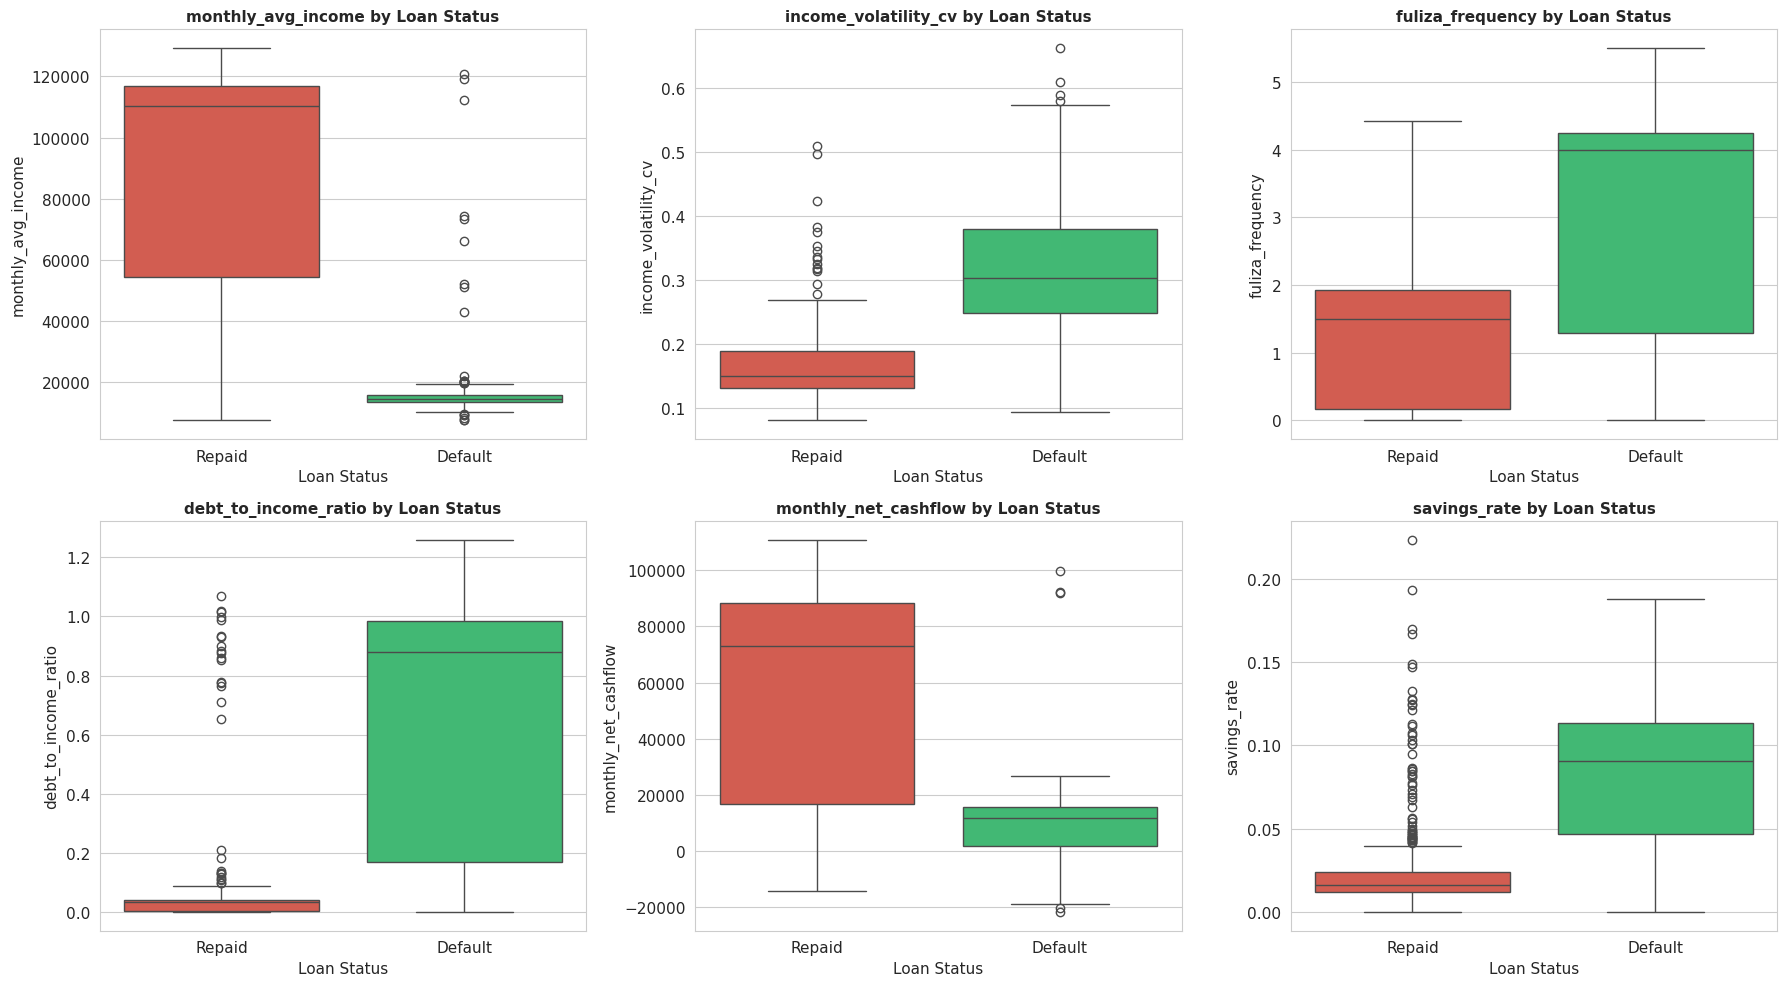


 Mean Comparison (Repaid vs Default):
   monthly_avg_income:
      - Repaid: 85773.350
      - Default: 16973.768
      - Difference: 68799.582
   income_volatility_cv:
      - Repaid: 0.165
      - Default: 0.317
      - Difference: -0.152
   fuliza_frequency:
      - Repaid: 1.175
      - Default: 3.220
      - Difference: -2.045
   debt_to_income_ratio:
      - Repaid: 0.047
      - Default: 0.707
      - Difference: -0.661
   monthly_net_cashflow:
      - Repaid: 54160.837
      - Default: 9175.891
      - Difference: 44984.946
   savings_rate:
      - Repaid: 0.022
      - Default: 0.081
      - Difference: -0.058


In [45]:
features_by_target(df)

In [32]:
def correlation_analysis(df):
    """Analyze correlations between features"""
    # Select key numeric features
    
    key_features = [
        'monthly_avg_income', 'income_volatility_cv', 'income_trend_6months',
        'monthly_net_cashflow', 'balance_min', 'months_balance_below_500',
        'fuliza_frequency', 'fuliza_repayment_rate', 'debt_to_income_ratio',
        'transaction_frequency', 'savings_rate', 'loan_status'
    ]
    
    # Filter columns that exist
    available_features = [f for f in key_features if f in df.columns]
    
    # Correlation matrix
    corr_matrix = df[available_features].corr()
    
    # Plot heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Top correlations with target
    target_corr = corr_matrix['loan_status'].abs().sort_values(ascending=False)
    print("\nTop 10 Features Correlated with Loan Repayment:")
    for idx, (feature, corr) in enumerate(target_corr[1:11].items(), 1):
        print(f"   {idx}. {feature}: {corr:.3f}")

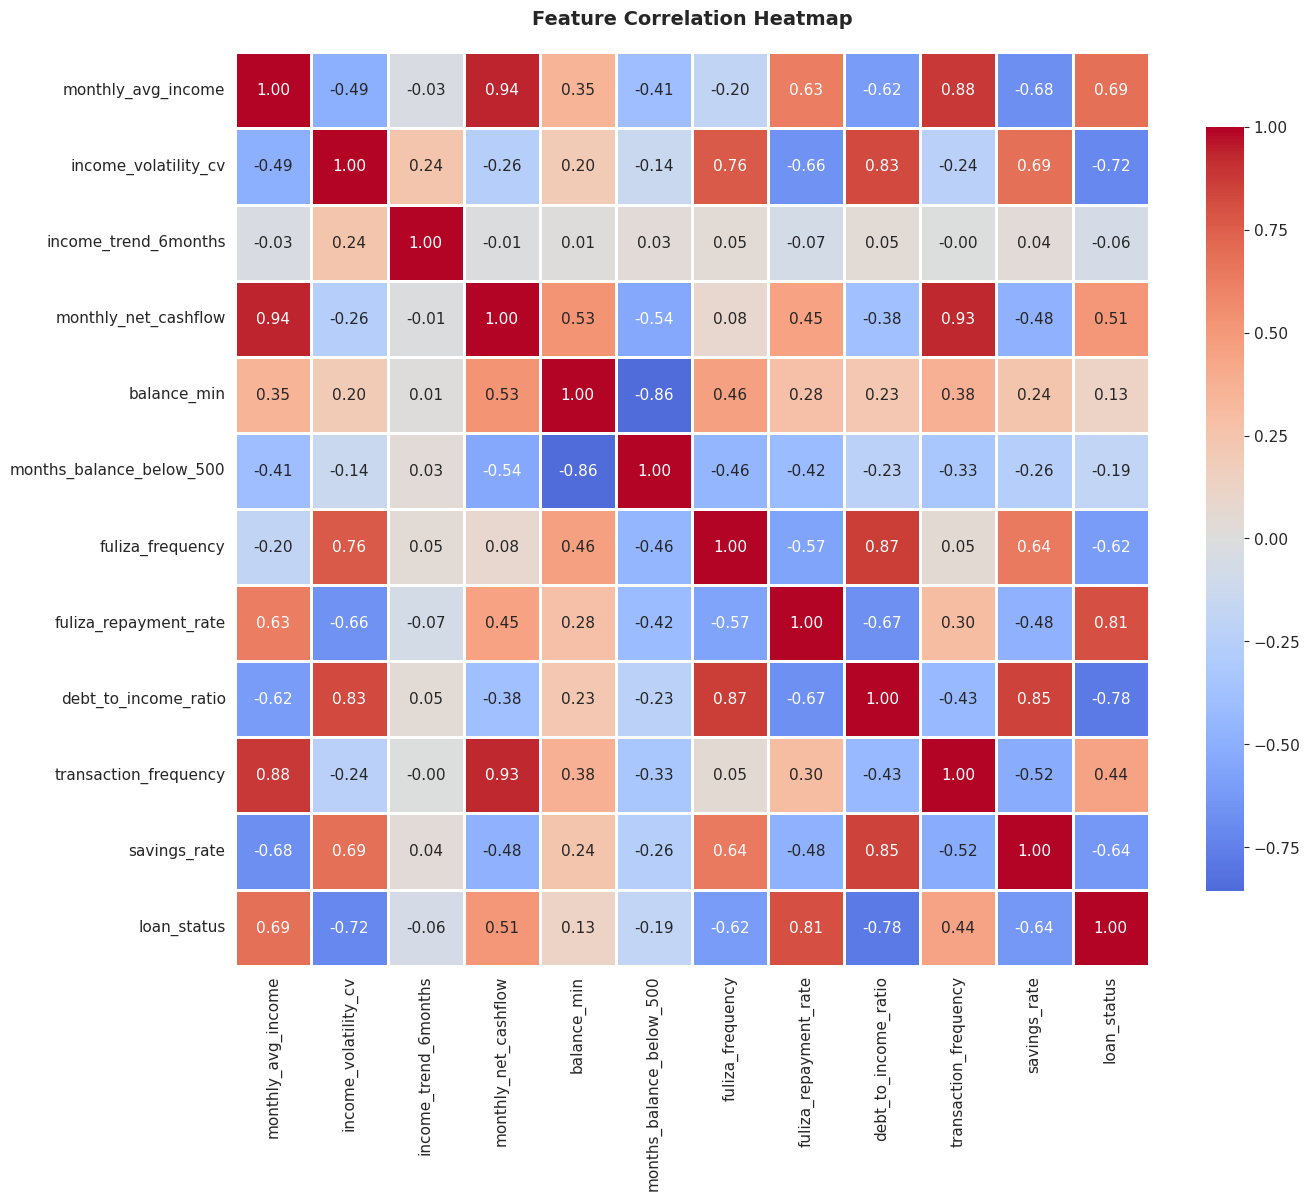


Top 10 Features Correlated with Loan Repayment:
   1. fuliza_repayment_rate: 0.809
   2. debt_to_income_ratio: 0.784
   3. income_volatility_cv: 0.715
   4. monthly_avg_income: 0.686
   5. savings_rate: 0.639
   6. fuliza_frequency: 0.615
   7. monthly_net_cashflow: 0.510
   8. transaction_frequency: 0.445
   9. months_balance_below_500: 0.187
   10. balance_min: 0.126


In [33]:
correlation_analysis(df)

In [46]:
def employment_type_analysis(df):
    """Analyze features by employment type"""
    
    if 'employment_type' not in df.columns:
        print("Employment type column not found. Skipping...")
        return
    
    # Create plot
    df_plot = df.copy()
    df_plot['loan_status_label'] = df_plot['loan_status'].map({0: 'Default', 1: 'Repaid'})
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Default rate by employment type
    emp_default = df_plot.groupby('employment_type')['loan_status'].apply(lambda x: (x==0).sum()/len(x)*100).reset_index()
    emp_default.columns = ['employment_type', 'default_rate']
    sns.barplot(data=emp_default, x='employment_type', y='default_rate', palette='Reds_r', ax=axes[0, 0])
    axes[0, 0].set_title('Default Rate by Employment Type', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Default Rate (%)')
    axes[0, 0].set_xlabel('Employment Type')
    axes[0, 0].tick_params(axis='x', rotation=45)
    for container in axes[0, 0].containers:
        axes[0, 0].bar_label(container, fmt='%.1f%%')
    
    # Income by employment type
    sns.boxplot(data=df, x='employment_type', y='monthly_avg_income', palette='Set2', ax=axes[0, 1])
    axes[0, 1].set_title('Income by Employment Type', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Monthly Income (KES)')
    axes[0, 1].set_xlabel('Employment Type')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Fuliza frequency by employment type
    sns.boxplot(data=df, x='employment_type', y='fuliza_frequency', palette='Set3', ax=axes[1, 0])
    axes[1, 0].set_title('Fuliza Frequency by Employment Type', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Fuliza Frequency (per month)')
    axes[1, 0].set_xlabel('Employment Type')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Loan status distribution by employment type
    emp_status = df.groupby(['employment_type', 'loan_status_label']).size().reset_index(name='count')
    sns.barplot(data=emp_status, x='employment_type', y='count', hue='loan_status_label',
               palette=['#e74c3c', '#2ecc71'], ax=axes[1, 1])
    axes[1, 1].set_title('Loan Status by Employment Type', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_xlabel('Employment Type')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].legend(title='Status')
    
    plt.tight_layout()
    plt.show()

ValueError: Grouper and axis must be same length

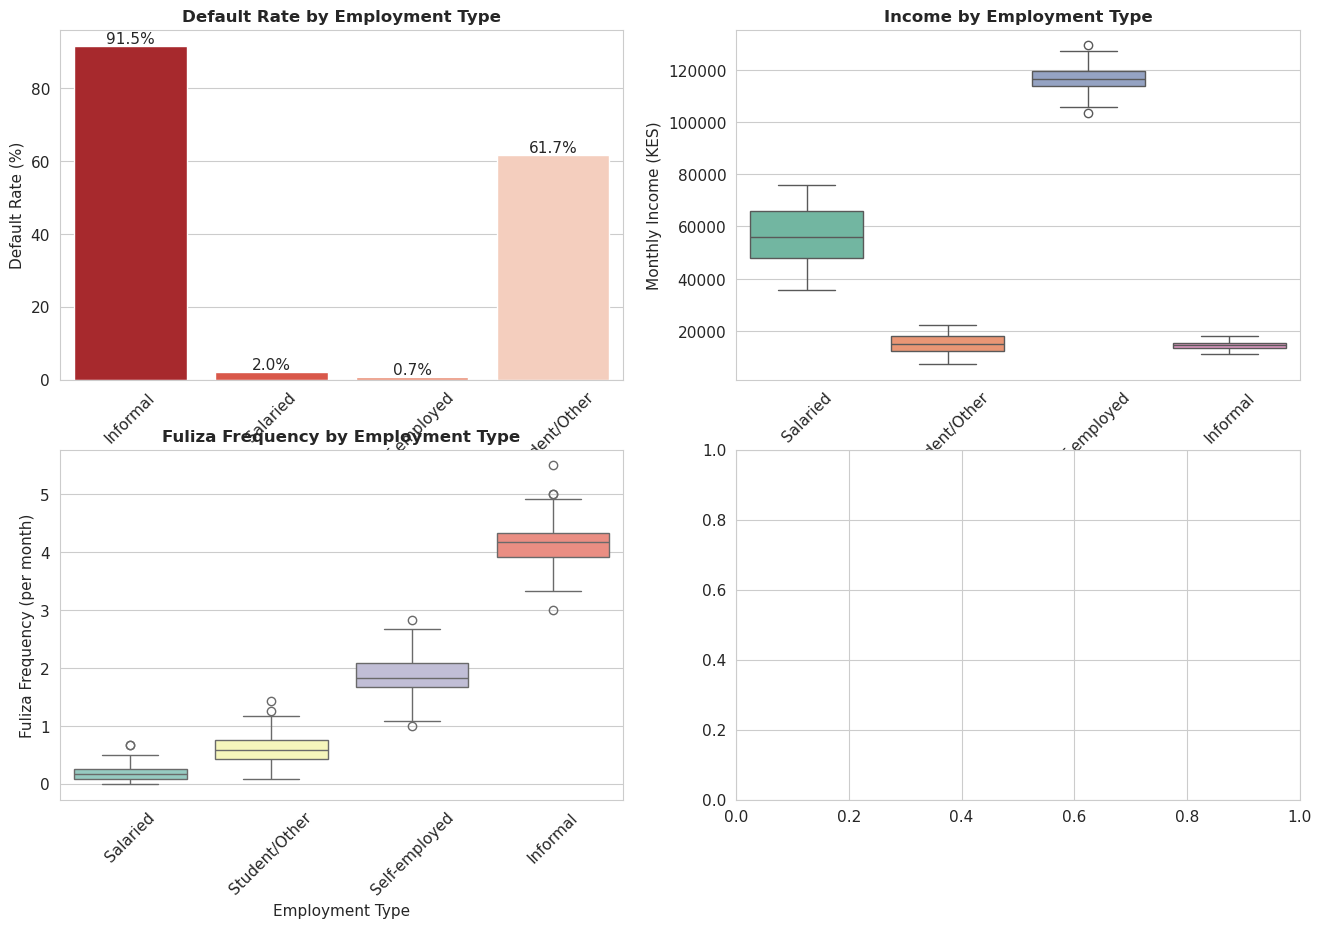

In [47]:
employment_type_analysis(df)